# CycleGAN on Horse2Zebra
 
**Date**: 2025/02/04

## 1. Introduction

In this notebook, we will demonstrate how to train (and infer) a [CycleGAN](https://arxiv.org/abs/1703.10593) model in PyTorch. CycleGAN introduced the concept of **unpaired image-to-image translation**: given two sets of images from domains $X$ and $Y$ (e.g., horses and zebras), we train two generators $G: X \to Y$ and $F: Y \to X$ and two discriminators $D_X, D_Y$. The core idea is to learn a mapping $G$ that transforms a sample from the horse domain to a zebra-like style and a mapping $F$ that does the reverse.

### Key Contributions of CycleGAN

1. **Unpaired image-to-image translation**: CycleGAN does not require paired training data, which drastically expands potential use cases.
2. **Cycle-consistency loss**: Ensures the mapping from $X \to Y$ and then $Y \to X$ reproduces the original sample (and vice versa).

### The Mathematical Formulation

Given two domains $X$ and $Y$, CycleGAN learns two generators:
$$
G : X \rightarrow Y, \quad F : Y \rightarrow X
$$
and two discriminators:
$$
D_X : X \rightarrow \{0, 1\}, \quad D_Y : Y \rightarrow \{0, 1\}
$$

![](https://production-media.paperswithcode.com/methods/Screen_Shot_2020-07-05_at_3.54.24_PM_aoT8JRU.png)

#### 1. Adversarial Loss

Adversarial loss for generator $G$ and discriminator $D_Y$ (mapping $X \to Y$):

$$
\mathcal{L}_{\text{GAN}}(G, D_Y, X, Y) = \mathbb{E}_{y \sim p_{\text{data}}(y)}[\log D_Y(y)] + \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log(1 - D_Y(G(x)))]
$$

And similarly for generator $F$ and discriminator $D_X$ (mapping $Y \to X$).

#### 2. Cycle-consistency Loss

To ensure the learned mappings are inverses of each other, CycleGAN introduces cycle-consistency losses:

$$
\mathcal{L}_{\text{cyc}}(G, F) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\| F(G(x)) - x\|_1] + \mathbb{E}_{y \sim p_{\text{data}}(y)}[\| G(F(y)) - y\|_1]
$$

This enforces $F(G(x)) \approx x$ and $G(F(y)) \approx y$.

#### 3. Identity Mapping Loss

To preserve color composition and encourage minimal changes when the image is already in the “target style”, an identity mapping loss is also introduced:

$$
\mathcal{L}_{\text{id}}(G, F) = \mathbb{E}_{y \sim p_{\text{data}}(y)}[\| G(y) - y\|_1] + \mathbb{E}_{x \sim p_{\text{data}}(x)}[\| F(x) - x\|_1]
$$

By combining these losses, the overall objective for CycleGAN becomes:

$$
\mathcal{L}(G, F, D_X, D_Y) = \mathcal{L}_{\text{GAN}}(G, D_Y, X, Y) + \mathcal{L}_{\text{GAN}}(F, D_X, Y, X) \\
\quad + \lambda_\text{cyc} \mathcal{L}_{\text{cyc}}(G, F) + \lambda_\text{id} \mathcal{L}_{\text{id}}(G, F)
$$

where $\lambda_\text{cyc}$ and $\lambda_\text{id}$ are weighting factors.

## 2. Downloading Pretrained Weights & Dataset

Next, we download the pretrained weights for the horse2zebra task and the actual dataset:

In [ ]:
!bash ../utils/models/CycleGAN/download_weights.sh horse2zebra "weights/CycleGAN/"
!bash ../utils/models/CycleGAN/download_dataset.sh "../data/"

## 3. Imports & Argument Setup

We import all necessary libraries, define our arguments, and set up reproducibility seeds:

In [ ]:
import itertools
import os
import random

import torch
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.transforms as transforms
from PIL import Image
from tqdm.auto import tqdm

# https://github.com/Lornatang/CycleGAN-PyTorch/tree/cdf7d443b7c5ff26623f601c29de38ce2dfbf679
from cyclegan_pytorch import DecayLR
from cyclegan_pytorch import Discriminator
from cyclegan_pytorch import Generator
from cyclegan_pytorch import ImageDataset
from cyclegan_pytorch import ReplayBuffer
from cyclegan_pytorch import weights_init

import matplotlib.pyplot as plt
import numpy as np

%pip install -q munch
from munch import Munch

In [ ]:
# Set up the hyperparameters and configuration
args = Munch()
args.dataroot = "../data"
args.dataset = "horse2zebra"

# Training and model configuration
args.epochs = 200
args.decay_epochs = 100
args.batch_size = 1
args.lr = 0.0002
args.print_freq = 100
args.cuda = False

# Path to pre-trained model weights
args.netG_A2B = f"./weights/CycleGAN/{args.dataset}/netG_A2B.pth"
args.netG_B2A = f"./weights/CycleGAN/{args.dataset}/netG_B2A.pth"
args.netD_A   = f"./weights/CycleGAN/{args.dataset}/netD_A.pth"
args.netD_B   = f"./weights/CycleGAN/{args.dataset}/netD_B.pth"

# Image configuration
args.image_size = 256

# Output folder
args.outf = "./outputs"

# Manual seed for reproducibility
args.manualSeed = None
if args.manualSeed is None:
    args.manualSeed = random.randint(1, 10000)
random.seed(args.manualSeed)
torch.manual_seed(args.manualSeed)

## 4. CUDNN and Dataset Preparation

We enable CUDNN optimizations, check for CUDA availability, and set up the horse2zebra dataset:

In [39]:
# Enable CuDNN benchmark (for faster training)
cudnn.benchmark = False

if torch.cuda.is_available() and not args.cuda:
    print("WARNING: You have a CUDA device, so you should probably run with --cuda")

# Create dataset
dataset = ImageDataset(
    root=os.path.join(args.dataroot, args.dataset),
    transform=transforms.Compose([
        transforms.Resize(int(args.image_size * 1.12), Image.BICUBIC),
        transforms.RandomCrop(args.image_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]),
    unaligned=True
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=args.batch_size,
    shuffle=True,
    pin_memory=True
)

## 5. Data Inspection

Let's look at a few random examples from the dataset. The dataset is unpaired, so left is from domain A (horse), right is from domain B (zebra).

In [ ]:
IMGS_CNT = 5
plt.figure(figsize=(17, 5 * IMGS_CNT))

for i, idx in enumerate(np.random.choice(np.arange(len(dataset)), size=IMGS_CNT, replace=False)):
    data = dataset[idx]
    img1, img2 = [(1+data[x])/2 for x in ['A', 'B']]  # Denormalize
    plt.subplot(IMGS_CNT, 2, 2*i+1)
    plt.imshow(img1.permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Domain A (Horse)")
    
    plt.subplot(IMGS_CNT, 2, 2*i+2)
    plt.imshow(img2.permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Domain B (Zebra)")

plt.tight_layout()
plt.show()

## 6. Model Initialization

We create and initialize our Generators and Discriminators. By default, these architectures are from the original CycleGAN paper, adapted in the `cyclegan_pytorch` library. The weights are either initialized or, if specified, loaded from the downloaded pre-trained weights.


In [50]:
device = torch.device("cuda" if args.cuda else "cpu")

# Create model
netG_A2B = Generator().to(device)
netG_B2A = Generator().to(device)
netD_A   = Discriminator().to(device)
netD_B   = Discriminator().to(device)

# Initialize weights
netG_A2B.apply(weights_init)
netG_B2A.apply(weights_init)
netD_A.apply(weights_init)
netD_B.apply(weights_init)

# Load pretrained weights if paths are provided
if args.netG_A2B != "":
    netG_A2B.load_state_dict(torch.load(args.netG_A2B, map_location=torch.device(device), weights_only=True))
if args.netG_B2A != "":
    netG_B2A.load_state_dict(torch.load(args.netG_B2A, map_location=torch.device(device), weights_only=True))
if args.netD_A != "":
    netD_A.load_state_dict(torch.load(args.netD_A, map_location=torch.device(device), weights_only=True))
if args.netD_B != "":
    netD_B.load_state_dict(torch.load(args.netD_B, map_location=torch.device(device), weights_only=True))

## 7. Quick Inference Check (Untrained or Pretrained Weights)

Here, we take some random samples from the dataset and see how the **generator** transforms them.

### 7.1. Translating from B (Zebra) to A (Horse)

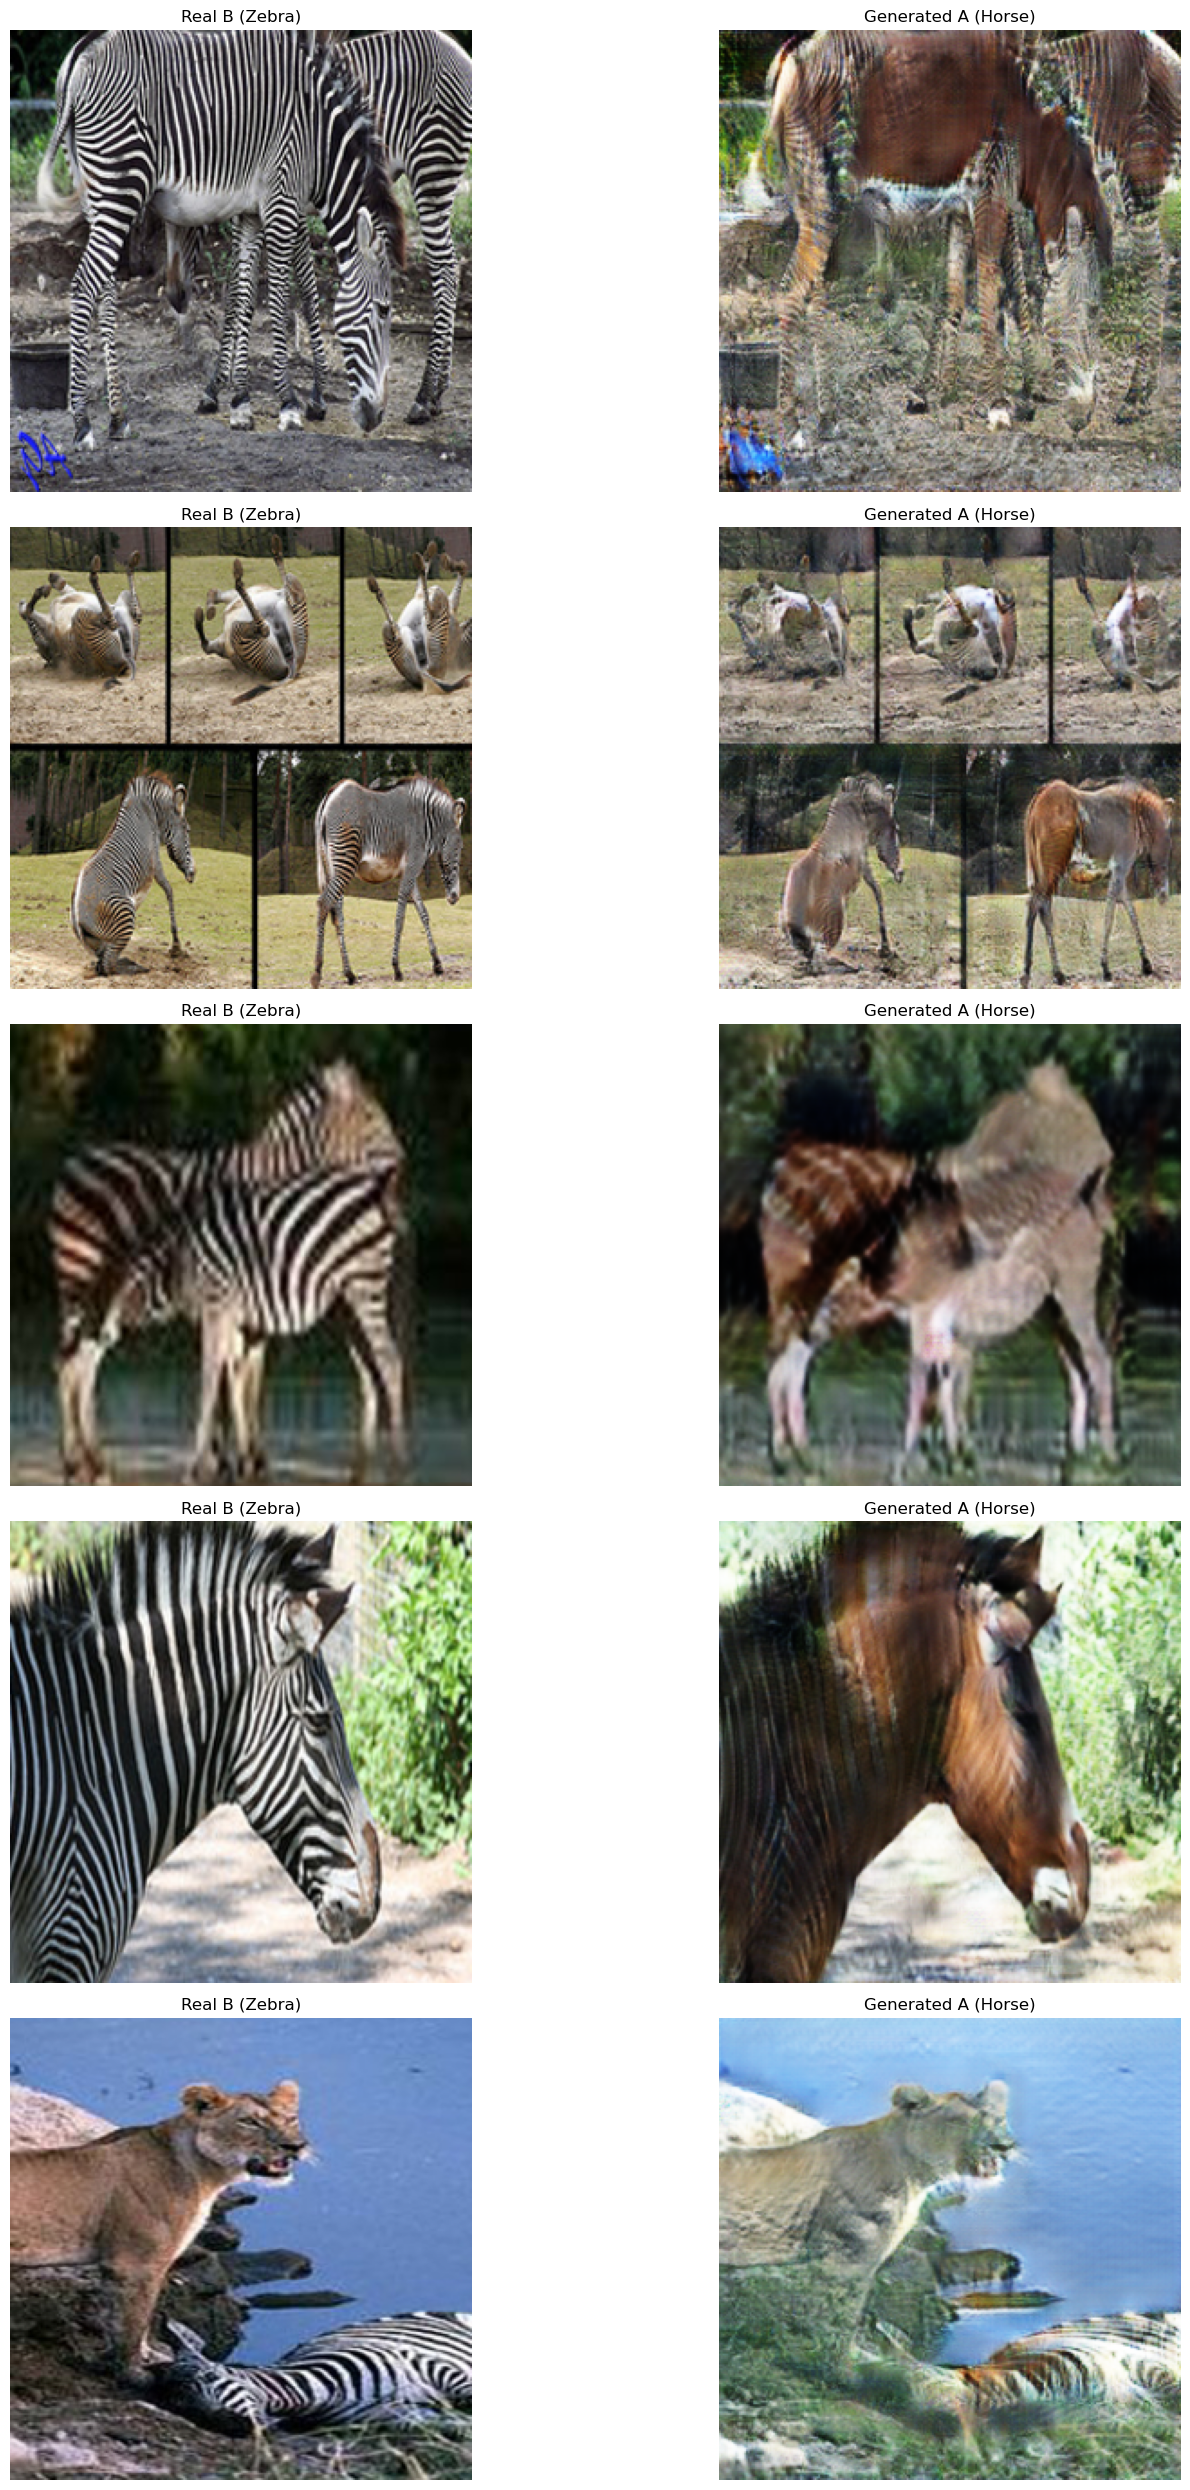

In [51]:
IMGS_CNT = 5
plt.figure(figsize=(17, 5*IMGS_CNT))

for i, idx in enumerate(np.random.choice(np.arange(len(dataset)), size=IMGS_CNT, replace=False)):
    data = dataset[idx]
    
    # Forward pass: B -> A
    fake_a = netG_B2A(data['B'].unsqueeze(0).to(device))[0]
    
    # Denormalize for display
    real_b, gen_a = [(1+x)/2 for x in [data['B'], fake_a]]
    
    plt.subplot(IMGS_CNT, 2, 2*i+1)
    plt.imshow(real_b.permute(1,2,0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Real B (Zebra)")
    
    plt.subplot(IMGS_CNT, 2, 2*i+2)
    plt.imshow(gen_a.permute(1,2,0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Generated A (Horse)")

plt.tight_layout()
plt.show()

### 7.2. Translating from A (Horse) to B (Zebra)

In [ ]:
IMGS_CNT = 5
plt.figure(figsize=(17, 5*IMGS_CNT))

for i, idx in enumerate(np.random.choice(np.arange(len(dataset)), size=IMGS_CNT, replace=False)):
    data = dataset[idx]
    
    # Forward pass: A -> B
    fake_b = netG_A2B(data['A'].unsqueeze(0).to(device))[0]
    
    # Denormalize for display
    real_a, gen_b = [(1+x)/2 for x in [data['A'], fake_b]]
    
    plt.subplot(IMGS_CNT, 2, 2*i+1)
    plt.imshow(real_a.permute(1,2,0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Real A (Horse)")
    
    plt.subplot(IMGS_CNT, 2, 2*i+2)
    plt.imshow(gen_b.permute(1,2,0).detach().cpu().numpy())
    plt.axis("off")
    plt.title("Generated B (Zebra)")

plt.tight_layout()
plt.show()

## 8. Defining Loss Functions and Optimizers

We define:

- **Adversarial loss** ($\ell_{GAN}$): $\text{MSELoss}$
- **Cycle consistency loss** ($\ell_{cyc}$): $L_1$ loss (scaled by 10.0 typically)
- **Identity loss** ($\ell_{id}$): $L_1$ loss (scaled by 5.0 typically)

We then create **Adam** optimizers for the two generators and two discriminators. Finally, we set up a learning rate scheduler that will linearly decay the learning rate after a certain epoch.

In [ ]:
# Define Losses
cycle_loss = torch.nn.L1Loss().to(device)
identity_loss = torch.nn.L1Loss().to(device)
adversarial_loss = torch.nn.MSELoss().to(device)

# Optimizers
optimizer_G = torch.optim.Adam(
    itertools.chain(netG_A2B.parameters(), netG_B2A.parameters()),
    lr=args.lr, betas=(0.5, 0.999)
)
optimizer_D_A = torch.optim.Adam(netD_A.parameters(), lr=args.lr, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(netD_B.parameters(), lr=args.lr, betas=(0.5, 0.999))

# Learning rate scheduling
lr_lambda = DecayLR(args.epochs, 0, args.decay_epochs).step
lr_scheduler_G   = torch.optim.lr_scheduler.LambdaLR(optimizer_G,   lr_lambda=lr_lambda)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=lr_lambda)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=lr_lambda)

# Buffers for historical generated images
fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

## 9. Training Loop

Below is the main training loop for CycleGAN. The procedure can be summarized as:

1. **Generate** fake images using both generators:
   - $\hat{B} = G_{A \to B}(A)$
   - $\hat{A} = G_{B \to A}(B)$
   
2. **Compute** the Identity Loss, Adversarial Loss, and Cycle Consistency Loss, and **update** the Generators.

3. **Update** each Discriminator ($D_A$ and $D_B$) using real samples and replay-buffer-sampled fake images.

By default, we are training for 200 epochs, with the learning rate linearly decaying after 100 epochs.

**Note**: Training from scratch can be computationally intense. 

In [ ]:
g_losses = []
d_losses = []

identity_losses = []
gan_losses = []
cycle_losses = []

for epoch in range(0, args.epochs):
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))
    for i, data in progress_bar:
        ##############################################
        # Prepare Inputs
        ##############################################
        real_image_A = data["A"].to(device)
        real_image_B = data["B"].to(device)
        batch_size = real_image_A.size(0)

        real_label = torch.full((batch_size, 1), 1, device=device, dtype=torch.float32)
        fake_label = torch.full((batch_size, 1), 0, device=device, dtype=torch.float32)

        ##############################################
        # (1) Update G network: Generators A2B and B2A
        ##############################################
        optimizer_G.zero_grad()

        # Identity Loss
        identity_image_A = netG_B2A(real_image_A)
        loss_identity_A = identity_loss(identity_image_A, real_image_A) * 5.0
        
        identity_image_B = netG_A2B(real_image_B)
        loss_identity_B = identity_loss(identity_image_B, real_image_B) * 5.0

        # GAN Loss
        fake_image_A = netG_B2A(real_image_B)
        fake_output_A = netD_A(fake_image_A)
        loss_GAN_B2A = adversarial_loss(fake_output_A, real_label)

        fake_image_B = netG_A2B(real_image_A)
        fake_output_B = netD_B(fake_image_B)
        loss_GAN_A2B = adversarial_loss(fake_output_B, real_label)

        # Cycle-consistency Loss
        recovered_image_A = netG_B2A(fake_image_B)
        loss_cycle_ABA = cycle_loss(recovered_image_A, real_image_A) * 10.0

        recovered_image_B = netG_A2B(fake_image_A)
        loss_cycle_BAB = cycle_loss(recovered_image_B, real_image_B) * 10.0

        # Combined Loss for Generators
        errG = (loss_identity_A + loss_identity_B 
                + loss_GAN_A2B + loss_GAN_B2A
                + loss_cycle_ABA + loss_cycle_BAB)

        errG.backward()
        optimizer_G.step()

        ##############################################
        # (2) Update D network: Discriminator A
        ##############################################
        optimizer_D_A.zero_grad()

        # Real A
        real_output_A = netD_A(real_image_A)
        errD_real_A = adversarial_loss(real_output_A, real_label)

        # Fake A
        fake_image_A = fake_A_buffer.push_and_pop(fake_image_A)
        fake_output_A = netD_A(fake_image_A.detach())
        errD_fake_A = adversarial_loss(fake_output_A, fake_label)

        errD_A = (errD_real_A + errD_fake_A) / 2
        errD_A.backward()
        optimizer_D_A.step()

        ##############################################
        # (3) Update D network: Discriminator B
        ##############################################
        optimizer_D_B.zero_grad()

        # Real B
        real_output_B = netD_B(real_image_B)
        errD_real_B = adversarial_loss(real_output_B, real_label)

        # Fake B
        fake_image_B = fake_B_buffer.push_and_pop(fake_image_B)
        fake_output_B = netD_B(fake_image_B.detach())
        errD_fake_B = adversarial_loss(fake_output_B, fake_label)

        errD_B = (errD_real_B + errD_fake_B) / 2
        errD_B.backward()
        optimizer_D_B.step()

        # Print training status
        progress_bar.set_description(
            f"[{epoch}/{args.epochs - 1}][{i}/{len(dataloader) - 1}] "
            f"Loss_D: {(errD_A + errD_B).item():.4f} "
            f"Loss_G: {errG.item():.4f} "
            f"Loss_G_identity: {(loss_identity_A + loss_identity_B).item():.4f} "
            f"loss_G_GAN: {(loss_GAN_A2B + loss_GAN_B2A).item():.4f} "
            f"loss_G_cycle: {(loss_cycle_ABA + loss_cycle_BAB).item():.4f}"
        )
    
    # Update learning rates
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()